#SVD(Singular Value Decomposition)
- SVD finds hidden taste patterns,measures how important they are, and expresses both users and movies in that hidden taste space.

In [ ]:
#SVD PDF: https://drive.google.com/file/d/1mdQUSe4zJsLyoqfpPqEK_I8qaTQFx7mN/view?usp=sharing

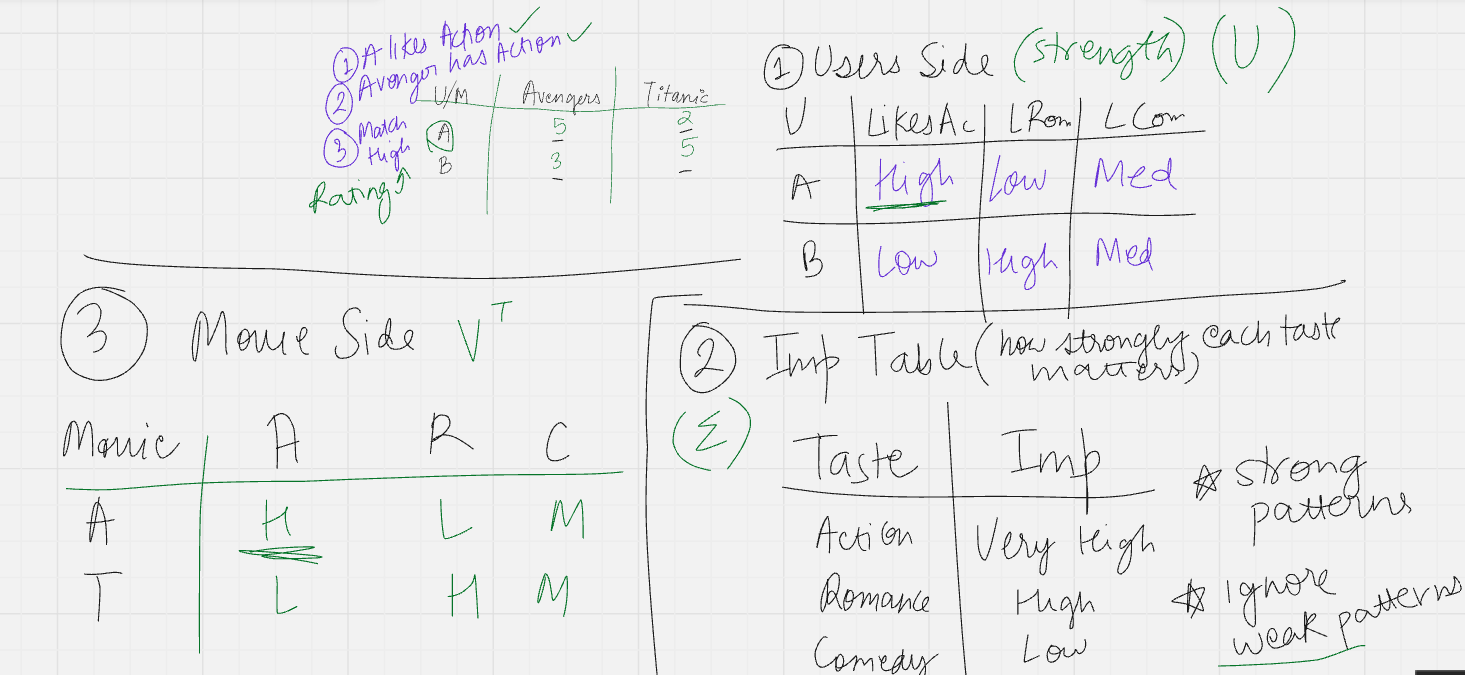


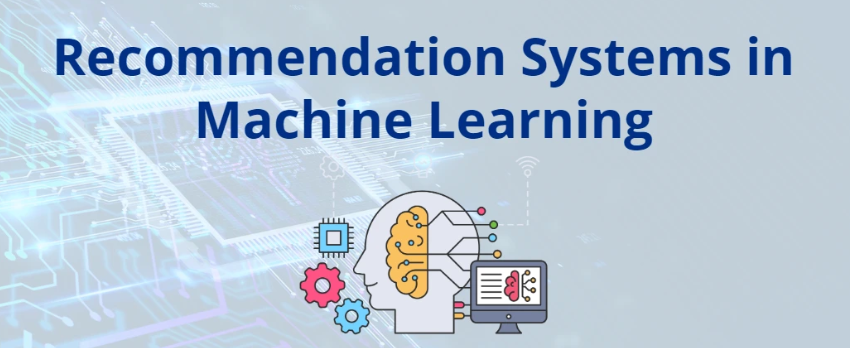

# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.

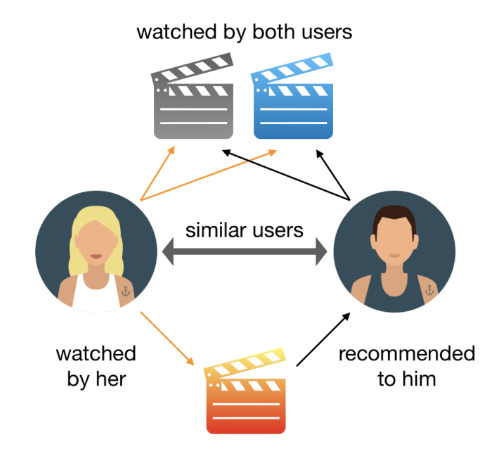


**SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities. Here's a basic idea without going deep into the topic**

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

**4) Step-by-Step Implementation of SVD in a Recommendation System**

Install and Import Libraries

Load and Prepare the Dataset

Train the SVD Model

Evaluate the Model

Make Predictions

In [3]:
# Dataset 1: https://drive.google.com/file/d/1nUAwFYxnGiPhFOgP4tiXwOkaL8BgCMQG/view?usp=sharing
# Dataset 2: https://drive.google.com/file/d/1_QXVewqmoXBF5tlr4iOPYVs_2XqrVwnF/view?usp=sharing

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#Drive mount
from google.colab import drive

In [16]:
#after running "from google.colab import drive" click on the third icon infile(drive)

In [17]:
drive.mount("/content/drive") #get the path of the drive folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#drive.mount() after running this,
#you will get an option to connect your drive with colab and a folder will appear in the files section(drive)

In [9]:
# header=None: pandas considers that first row is the column name

In [18]:
netflix_dataset=pd.read_csv("/content/combined_data_1.txt.zip", header=None, names=['Cust_ID','Rating'], usecols=[0,1])
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


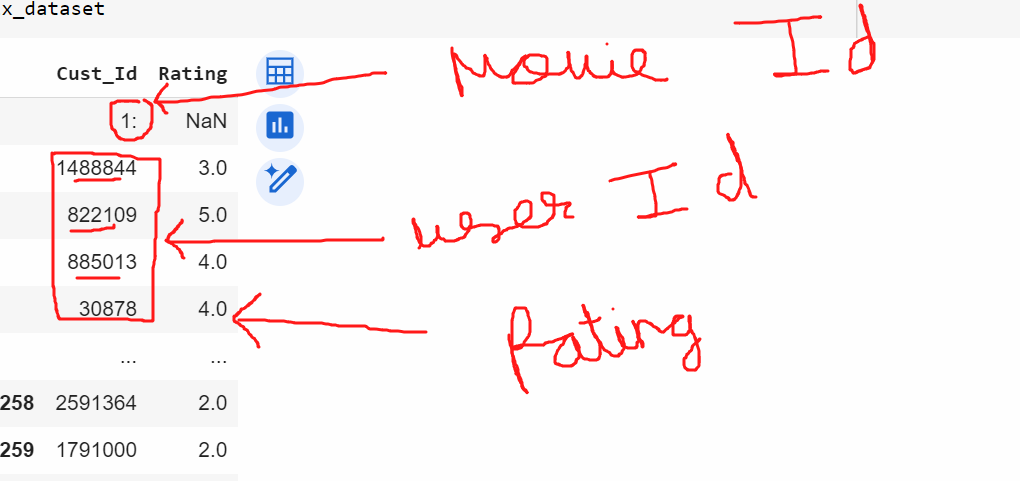

In [ ]:
#for every movie id we have null value in ratings and since 4499 null values are in ratings
# that mean 4499 movie ids are existing

In [19]:
netflix_dataset.isnull().sum()
#the 4499 null values are movie ids having rating value as NAN

,0
Cust_ID,0
Rating,4499


In [20]:
#get the count of movies with the help of cust_id and rating
movie_count=netflix_dataset.isnull().sum() #custid=0,rating=4499, is a series
movie_count=movie_count['Rating']
movie_count

4499

In [21]:
total_count=netflix_dataset['Cust_ID'].nunique()

In [22]:
total_count #cust id + movie id (both unique)

475257

In [23]:
#calculate customer count
customer_count=total_count-movie_count#subtract total-movie = customer ids
customer_count

470758

In [24]:
#calculate how many ratings do we have that are given by user
rating_count=netflix_dataset['Cust_ID'].count()-movie_count
rating_count

24053764

In [25]:
#to find how many users have rated the movies as 1,2,3,4,5 stars
stars=netflix_dataset['Rating'].value_counts()
stars

,count
Rating,
4.0,8085741
3.0,6904181
5.0,5506583
2.0,2439073
1.0,1118186


In [26]:
#Lets just make a clear dataframe to find how many movie ids are there

movie_id=None
movie_np=[] #empty list to store all movie ids

#Iterating over the dataframe rows
for i in netflix_dataset['Cust_ID']:
  if ":" in i:
    #Updating the current movie ID in column
    movie_id=int(i.replace(":"," "))
  movie_np.append(movie_id)

In [27]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [28]:
#Create a new column in the dataset that stores movie_np list data(all the movie ids)
netflix_dataset['MovieID']=movie_np

In [29]:
netflix_dataset

,Cust_ID,Rating,MovieID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [30]:
netflix_dataset.dropna(inplace=True)

In [31]:
netflix_dataset

,Cust_ID,Rating,MovieID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [32]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_ID  object 
 1   Rating   float64
 2   MovieID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [33]:
#change the datatype of cust_id from object to int
netflix_dataset['Cust_ID']=netflix_dataset['Cust_ID'].astype(int)

In [34]:
netflix_dataset

,Cust_ID,Rating,MovieID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [35]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_ID  int64  
 1   Rating   float64
 2   MovieID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [ ]:
#PRE-FILTERING
#1. Remove all the users that have rated less number of movie
#2. Remove all the movies that have received less number of ratings

In [36]:
dataset_movie_summary=netflix_dataset['MovieID'].value_counts()
dataset_movie_summary

,count
MovieID,
1905,193941
2152,162597
3860,160454
4432,156183
571,154832
...,...
4294,44
915,43
3656,42


In [37]:
#Creating a benchmark
movie_benchmark=round(dataset_movie_summary.quantile(0.6),0) #0 rounds off the value to a whole number
print(movie_benchmark) #a movie should have atleast 908 ratings

908.0


In [38]:
#If any movie is having ratings less than 908, exclude it
drop_movie_list=dataset_movie_summary[dataset_movie_summary<movie_benchmark].index
drop_movie_list

Index([1598, 1733, 1647, 4099, 1616, 1446,  263, 4259,  160, 1988,
       ...
       1858, 4035, 3693, 2805,  820, 4294,  915, 3656, 4338, 4362],
      dtype='int64', name='MovieID', length=2699)

In [39]:
len(drop_movie_list) #index of the movies that have ratings<908

2699

In [40]:
#USers that are inactive
dataset_cust_summary=netflix_dataset['Cust_ID'].value_counts()
dataset_cust_summary

,count
Cust_ID,
305344,4467
387418,4422
2439493,4195
1664010,4019
2118461,3769
...,...
1300341,1
2550360,1
11848,1


In [41]:
cust_benchmark=round(dataset_cust_summary.quantile(0.6),0)
cust_benchmark #a user should have given atleast 36 ratings

36.0

In [42]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary<cust_benchmark].index
drop_cust_list

Index([2194851,  600295, 1739398, 1157368,  532108, 2157249,  256134,  640441,
       1272324, 1346990,
       ...
       1969065,  899932,  611596, 2147176,  811650, 1300341, 2550360,   11848,
        930788,  594210],
      dtype='int64', name='Cust_ID', length=282042)

In [43]:
len(drop_cust_list) #index of users that have given < 36 ratings

282042

In [44]:
#~+.isin = is not in
netflix_dataset=netflix_dataset[~netflix_dataset['MovieID'].isin(drop_movie_list)] #if from MovieID column, any movie is not in drop_movie_list, put it back in netflix dataset
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_ID'].isin(drop_cust_list)] #if from Cust_ID column, any customer is not in drop_cust_list, put it back in netflix dataset

In [45]:
netflix_dataset

,Cust_ID,Rating,MovieID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


#Model Building

In [46]:
#Load the second dataset for movie names as with previous dataset we one have movie id

#encoding=surpasses special characters
df_title=pd.read_csv("/content/movies.csv", encoding="ISO-8859-1", usecols=[0,1,2])
df_title

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [39]:
 #!pip install numpy==1.26.4

In [ ]:
#1. Downgrade numpy
#2. comment the code, restart the session and install scikit-surprise

In [40]:
!pip install scikit-surprise

In [47]:
#Dataset: is helping convert data to the format of SVD
#Reader: reads the data, since dataset module cannot read dataframe

from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [48]:
reader=Reader()

In [49]:
data=Dataset.load_from_df(netflix_dataset[['Cust_ID','MovieID','Rating']][:100000],reader)
data

In [ ]:
#data stored at a given address
#Dataset.load_from_df: surprise has its own database where we are dumping our data since SVD cannot read data otherwise
#Class has an object and data is stored wrt object(type of class) similarly SVD is the class and it needs data of its type

In [105]:
model=SVD() #creating a SVD model

# Train the model on the entire dataset
trainset = data.build_full_trainset()
model.fit(trainset)


In [51]:
#Training the SVD model with top 100k data
cross_validate(model,data,measures=['RMSE'],cv=3)

{'test_rmse': array([1.01821016, 1.01916835, 1.02133511]),
 'fit_time': (1.3533587455749512, 2.0713257789611816, 1.4750921726226807),
 'test_time': (0.4718017578125, 0.1918783187866211, 0.1733849048614502)}

In [52]:
netflix_dataset

,Cust_ID,Rating,MovieID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


#Recommendation


In [53]:
#Filter the data for finding a specific user to whom we are going to suggest movies

user_rating=netflix_dataset[netflix_dataset['Cust_ID']==1331154]
user_rating

,Cust_ID,Rating,MovieID
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [54]:
#user 1331154 has rated 253 movies

In [54]:
user_1331154=df_title.copy()
user_1331154

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [55]:
#Remove the less rated movies from 2nd dataset also

user_1331154=user_1331154[~user_1331154['movieId'].isin(drop_movie_list)]

In [56]:
user_1331154

,movieId,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
7,8,Tom and Huck (1995),Adventure|Children
15,16,Casino (1995),Crime|Drama
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [57]:
#Prediction part

user_1331154['Estimated_Score']=user_1331154['movieId'].apply(lambda x:model.predict(1331154,x).est)
#Estimate out of 5
#Using movieId column, the trained SVD model predicts the rating that user 1331154 would give to movie "x",
#.est- gives an estimated value between 1-5

/tmp/ipykernel_12693/3151711756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154['Estimated_Score']=user_1331154['movieId'].apply(lambda x:model.predict(1331154,x).est)


In [58]:
user_1331154

,movieId,title,genres,Estimated_Score
2,3,Grumpier Old Men (1995),Comedy|Romance,3.817635
4,5,Father of the Bride Part II (1995),Comedy,4.450639
5,6,Heat (1995),Action|Crime|Thriller,3.600059
7,8,Tom and Huck (1995),Adventure|Children,3.746555
15,16,Casino (1995),Crime|Drama,3.065212
...,...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy,3.649146
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,3.649146
27275,131258,The Pirates (2014),Adventure,3.649146
27276,131260,Rentun Ruusu (2001),(no genres listed),3.649146


In [59]:
#Display top 5 movies with the highest estimate score that user 1331154 may like?

user_1331154.sort_values("Estimated_Score",ascending=False,inplace=True)

/tmp/ipykernel_12693/22999153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154.sort_values("Estimated_Score",ascending=False,inplace=True)


In [60]:
user_1331154.head(5)

,movieId,title,genres,Estimated_Score
4,5,Father of the Bride Part II (1995),Comedy,4.450639
24,25,Leaving Las Vegas (1995),Drama|Romance,3.861153
2,3,Grumpier Old Men (1995),Comedy|Romance,3.817635
27,28,Persuasion (1995),Drama|Romance,3.779185
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,3.774501


In [ ]:
#assignment questions and answers are from below onwards:


In [ ]:
#1. Find out the list of most popular and liked genre

In [62]:
# Merge rating data with movie titles using the correct column names for Movie IDs
df = pd.merge(netflix_dataset, df_title, left_on='MovieID', right_on='movieId', how='inner')

In [63]:
# Most Popular Genre (based on number of ratings)
popular_genre = df.groupby('genres')['Rating'].count().sort_values(ascending=False)

In [64]:
print("Most Popular Genres:")
print(popular_genre)

Most Popular Genres:
genres
Drama                                   3567796
Comedy                                  2072382
Horror                                   940504
Comedy|Drama                             906216
Drama|Romance                            827549
                                         ...   
Action|Adventure|Crime|Drama|Western        909
Animation|Horror|IMAX                       891
Drama|Fantasy|Mystery                       887
Drama|Fantasy|Horror|Thriller               836
Drama|Film-Noir|Mystery|Thriller            726
Name: Rating, Length: 304, dtype: int64


In [65]:
# Most Liked Genre (based on average rating)
liked_genre = df.groupby('genres')['Rating'].mean().sort_values(ascending=False)

In [66]:
print("\nMost Liked Genres:")
print(liked_genre)


Most Liked Genres:
genres
Action|Crime|Mystery|Thriller                          4.495253
Comedy|Musical|War                                     4.436311
Drama|Fantasy|Horror|Thriller                          4.337321
Action|Adventure|Children                              4.329389
Adventure|Animation|Children|Comedy|Fantasy|Romance    4.313539
                                                         ...   
Action|Children                                        2.604922
Adventure|Children|Romance                             2.492969
Action|Adventure|Children|Fantasy                      2.444971
Action|Drama|Romance                                   2.440416
Horror|Western                                         2.282623
Name: Rating, Length: 304, dtype: float64


In [67]:
# Visualization
import matplotlib.pyplot as plt


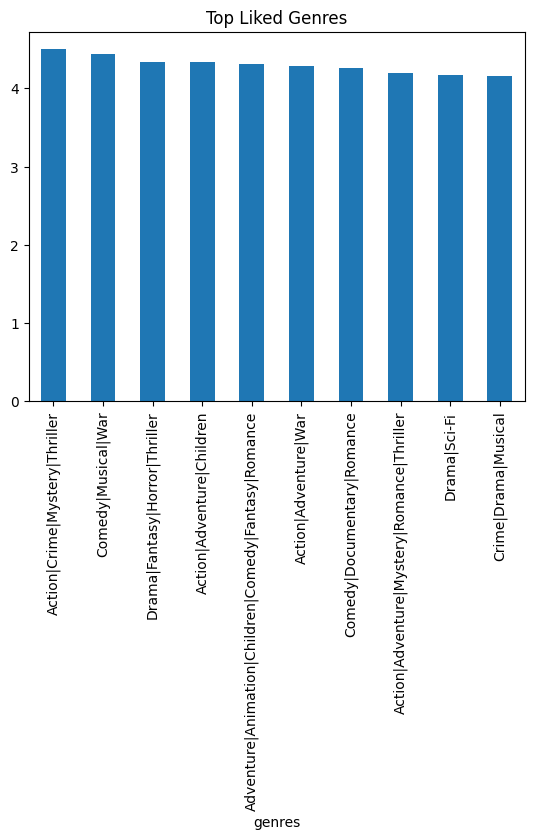

In [68]:
liked_genre.head(10).plot(kind='bar', title='Top Liked Genres')
plt.show()

In [ ]:
#2. Create Model that finds the best suited Movie for one user in every genre.

In [107]:
# choose a user
user_id = netflix_dataset['Cust_ID'].iloc[0]

In [108]:
user_id

712664

In [132]:
# unique movies
movies = df_title[['movieId','title','genres']].drop_duplicates()


In [144]:
# Get the list of movie IDs that the SVD model was trained on
# The SVD model was trained on data from netflix_dataset, specifically the first 100,000 rows.
# We need to ensure that the movies we try to predict for were part of the training data.
known_movie_ids = netflix_dataset['MovieID'].iloc[:100000].unique()


In [145]:
movies = movies[movies['movieId'].isin(known_movie_ids)]

In [146]:
movies

,movieId,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
7,8,Tom and Huck (1995),Adventure|Children
15,16,Casino (1995),Crime|Drama
16,17,Sense and Sensibility (1995),Drama|Romance
17,18,Four Rooms (1995),Comedy
23,24,Powder (1995),Drama|Sci-Fi
24,25,Leaving Las Vegas (1995),Drama|Romance
25,26,Othello (1995),Drama


In [147]:
predictions = []



In [152]:
for movie_id_val in movies['movieId']:
    try:
        pred = model.predict(user_id, movie_id_val)
        predictions.append((movie_id_val, pred.est))
    except Exception as e:
        # It's good practice to at least print the exception or log it
        # print(f"Error predicting for movie ID {movie_id_val}: {e}")
        continue

In [153]:
import pandas as pd



In [154]:
pred_df = pd.DataFrame(predictions, columns=['movieId','Predicted_Rating'])

In [155]:
pred_df.head()

,movieId,Predicted_Rating
0,3,4.360547
1,5,4.189400
2,6,3.782699
3,8,3.247063
4,16,3.070576


In [156]:
# merge with movie info
pred_df = pred_df.merge(movies, on='movieId')

In [157]:
pred_df.head()

,movieId,Predicted_Rating,title,genres
0,3,4.360547,Grumpier Old Men (1995),Comedy|Romance
1,5,4.189400,Father of the Bride Part II (1995),Comedy
2,6,3.782699,Heat (1995),Action|Crime|Thriller
3,8,3.247063,Tom and Huck (1995),Adventure|Children
4,16,3.070576,Casino (1995),Crime|Drama


In [158]:
# best movie per genre
best_movies = pred_df.sort_values('Predicted_Rating', ascending=False).groupby('genres').head(1)

In [159]:
best_movies[['genres','title','Predicted_Rating']]

,genres,title,Predicted_Rating
0,Comedy|Romance,Grumpier Old Men (1995),4.360547
1,Comedy,Father of the Bride Part II (1995),4.189400
8,Drama|Romance,Leaving Las Vegas (1995),4.096233
2,Action|Crime|Thriller,Heat (1995),3.782699
11,Crime|Drama,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,3.687313
7,Drama|Sci-Fi,Powder (1995),3.359516
3,Adventure|Children,Tom and Huck (1995),3.247063
9,Drama,Othello (1995),2.992084


In [160]:
print("Best Recommended Movie in Each Genre:")
print(best_movies[['genres','title','Predicted_Rating']])


Best Recommended Movie in Each Genre:
                   genres                                              title  \
0          Comedy|Romance                            Grumpier Old Men (1995)   
1                  Comedy                 Father of the Bride Part II (1995)   
8           Drama|Romance                           Leaving Las Vegas (1995)   
2   Action|Crime|Thriller                                        Heat (1995)   
11            Crime|Drama  Shanghai Triad (Yao a yao yao dao waipo qiao) ...   
7            Drama|Sci-Fi                                      Powder (1995)   
3      Adventure|Children                                Tom and Huck (1995)   
9                   Drama                                     Othello (1995)   

    Predicted_Rating  
0           4.360547  
1           4.189400  
8           4.096233  
2           3.782699  
11          3.687313  
7           3.359516  
3           3.247063  
9           2.992084  


In [ ]:
#3. Find what Genre Movies have received the best and worst ratings based on User Rating.

In [69]:
genre_rating = df.groupby('genres')['Rating'].mean().sort_values(ascending=False)

In [70]:
best_genre = genre_rating.head(1)

In [71]:

worst_genre = genre_rating.tail(1)

In [72]:
print("Best Rated Genre:")
print(best_genre)

Best Rated Genre:
genres
Action|Crime|Mystery|Thriller    4.495253
Name: Rating, dtype: float64


In [73]:
print("\nWorst Rated Genre:")
print(worst_genre)


Worst Rated Genre:
genres
Horror|Western    2.282623
Name: Rating, dtype: float64


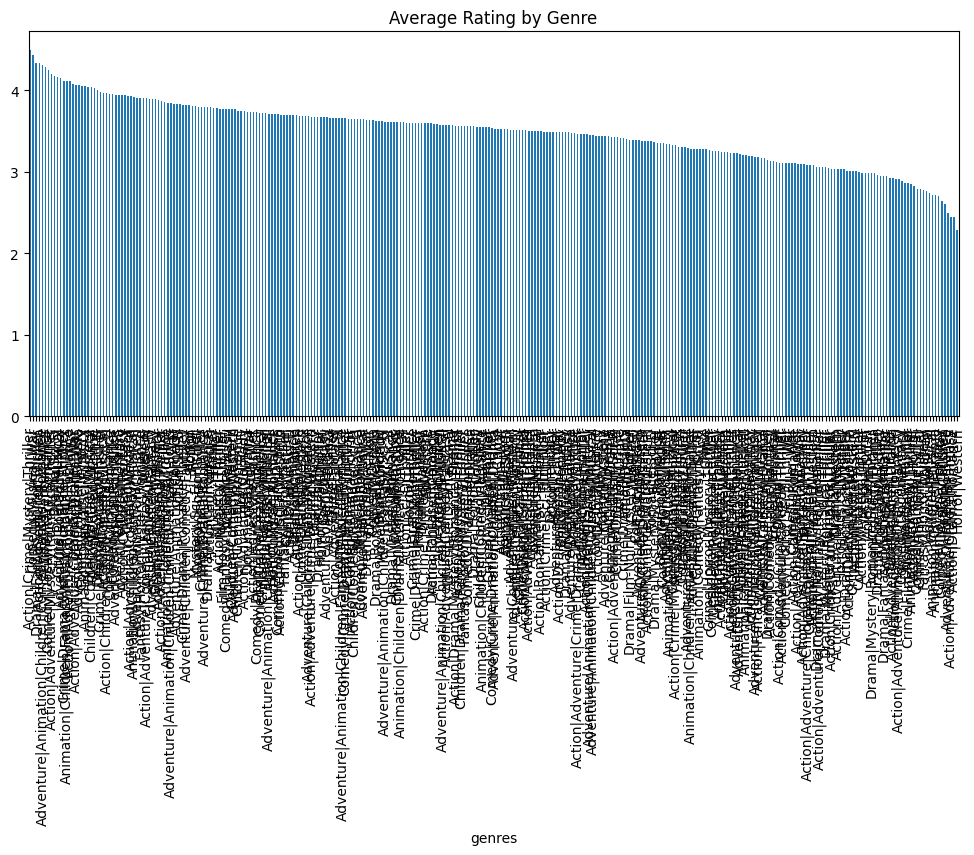

In [74]:
# visualization
genre_rating.plot(kind='bar', figsize=(12,5), title='Average Rating by Genre')
plt.show()